# Pairwise Gaussian Limit Comparison

This notebook compares the simulated pairwise Gaussian integral approximations in `pairwise_gaussian_estimate1` against the empirical pairwise Wasserstein distributions saved in `AVMs5a`.


In [30]:
from functools import lru_cache
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

mpl.rcParams['font.size'] = 14
PAIRWISE_GAUSSIAN_ROOT = Path("pairwise_gaussian_estimate1")
AVM_ROOT = Path("AVMs5a")
GROUPS = ("paths1", "paths2")
OBSERVABLES = ("theta1", "w1", "theta2", "w2")
ALPHAS = (0.01, 0.05, 0.1)
EMPIRICAL_SCALE = np.sqrt(100_002 - 50_000)
LABELS = {
    "theta1": r"$\theta_1$",
    "w1": r"$\omega_1$",
    "theta2": r"$\theta_2$",
    "w2": r"$\omega_2$",
}


def load_pairwise_gaussian(group: str, observable: str) -> np.ndarray:
    path = PAIRWISE_GAUSSIAN_ROOT / group / f"{observable}_pairwise_gaussian_integrals.npy"
    if not path.exists():
        raise FileNotFoundError(f"Missing Gaussian simulation file: {path}")
    values = np.load(path)
    return np.asarray(values, dtype=float)


@lru_cache(maxsize=None)
def load_avm_workbook(group: str) -> dict[str, pd.DataFrame]:
    workbook = AVM_ROOT / f"{group}_results.xlsx"
    if not workbook.exists():
        raise FileNotFoundError(f"Missing AVMs5a workbook: {workbook}")
    return pd.read_excel(workbook, sheet_name=None, index_col=0)


def load_avm_pairwise_values(group: str, observable: str) -> np.ndarray:
    workbook_sheets = load_avm_workbook(group)
    if observable not in workbook_sheets:
        raise KeyError(f"Sheet {observable!r} not found in AVMs5a workbook for {group}")

    matrix_df = workbook_sheets[observable]
    matrix = matrix_df.to_numpy(dtype=float)
    upper_triangle_mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)
    values = matrix[upper_triangle_mask & np.isfinite(matrix)]
    return EMPIRICAL_SCALE * values


def compare_group(group: str, bins: int = 40) -> pd.DataFrame:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    axes = axes.ravel()
    summary_rows = []

    for ax, observable in zip(axes, OBSERVABLES):
        gaussian_values = load_pairwise_gaussian(group, observable)
        avm_values = load_avm_pairwise_values(group, observable)

        combined = np.concatenate([gaussian_values, avm_values])
        bin_edges = np.linspace(combined.min(), combined.max(), bins + 1)
        avm_q95 = np.quantile(avm_values, 0.95)
        gaussian_q95 = np.quantile(gaussian_values, 0.95)

        ax.hist(
            avm_values,
            bins=bin_edges,
            density=True,
            alpha=0.45,
            color="#c44e52",
            label="Empirical pairwise distribution",
        )
        ax.hist(
            gaussian_values,
            bins=bin_edges,
            density=True,
            alpha=0.45,
            color="#4c72b0",
            label="Theoretical limiting distribution",
        )

        ax.axvline(
            avm_q95,
            color="#c44e52",
            linestyle="--",
            linewidth=1.5,
            label="Empirical 95th quantile",
            # ymax=0.7
        )
        ax.axvline(
            gaussian_q95,
            color="#4c72b0",
            linestyle="--",
            linewidth=1.5,
            label="Theoretical 95th quantile",
            # ymax=0.7
        )

        ax.set_title(f"Observable: {LABELS[observable]}")
        if observable in ["theta2", "w2"]:
            ax.set_xlabel("Scaled pairwise Wasserstein statistic")
        if observable in ["theta1", "theta2"]:
            ax.set_ylabel("Density")
        if observable == "theta1":
            ax.legend(frameon=True, loc = "upper right")

        summary_rows.append(
            {
                "group": group,
                "observable": observable,
                "avm_count": avm_values.size,
                "gaussian_count": gaussian_values.size,
                "avm_mean": avm_values.mean(),
                "gaussian_mean": gaussian_values.mean(),
                "avm_std": avm_values.std(ddof=1),
                "gaussian_std": gaussian_values.std(ddof=1),
            }
        )

    # fig.suptitle(f"Scaled Pairwise Wasserstein Distances vs. Theoretical Distribution ({"Convergent" if group == "paths1" else "Divergent"} Case)", fontsize=16)
    plt.show()
    return pd.DataFrame(summary_rows)


def compute_empirical_acceptance_table(alpha_levels: tuple[float, ...] = ALPHAS) -> pd.DataFrame:
    rows = []

    for group in GROUPS:
        for observable in OBSERVABLES:
            gaussian_values = load_pairwise_gaussian(group, observable)
            avm_values = load_avm_pairwise_values(group, observable)

            for alpha in alpha_levels:
                theoretical_cutoff = np.quantile(gaussian_values, 1 - alpha)
                empirical_acceptance_rate = np.mean(avm_values <= theoretical_cutoff)
                empirical_rejection_rate = 1.0 - empirical_acceptance_rate

                rows.append(
                    {
                        "group": group,
                        "observable": observable,
                        "alpha": alpha,
                        "theoretical_cutoff": theoretical_cutoff,
                        "empirical_acceptance_rate": empirical_acceptance_rate,
                        "empirical_rejection_rate": empirical_rejection_rate,
                    }
                )

    return pd.DataFrame(rows)


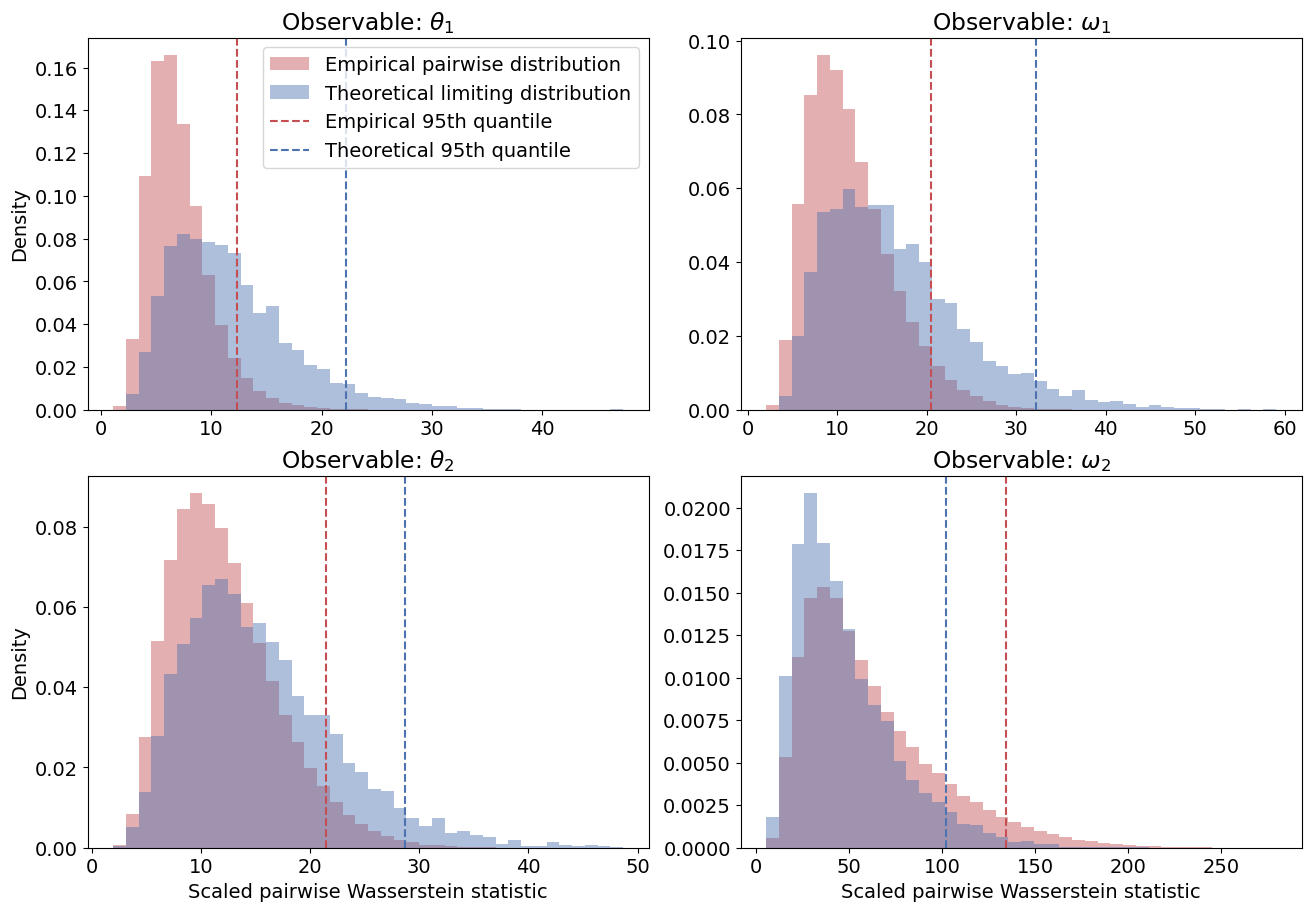

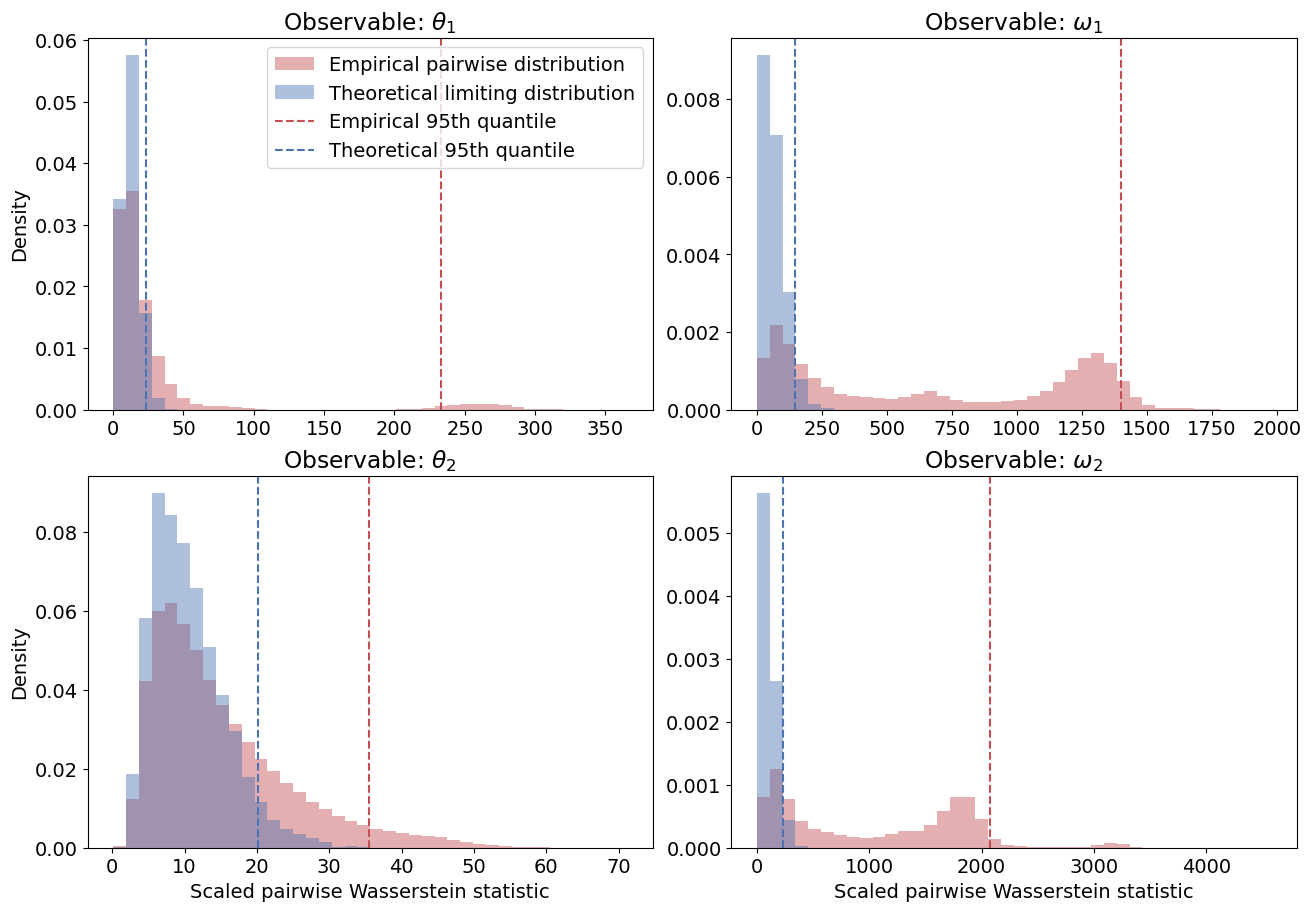

In [31]:
summaries = []
for group in GROUPS:
    summaries.append(compare_group(group))

# summary_df = pd.concat(summaries, ignore_index=True)
# empirical_acceptance_df = compute_empirical_acceptance_table()

# display(summary_df)
# empirical_acceptance_df
